# Final Table And Object Integration

This notebook builds the final table and integrates detections into object IDs.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import config
from final_table import build_final_table
from object_integration import integrate_objects
from IPython.display import display
from visualize_dbscan import plot_static_clusters, summarize_registry


In [2]:
final_args = SimpleNamespace(
    input_csv=config.PROJECTED_DETECTIONS_CSV,
    output_csv=config.FINAL_TABLE_CSV,
    timestamp_lookup_csv=config.TIMESTAMP_LOOKUP_CSV,
)

final_rows = build_final_table(final_args)
len(final_rows), final_rows[:2]

Final table: 100%|██████████| 77343/77343 [00:17<00:00, 4496.23object/s]


(77343,
 [{'image_name': 'IR_57327.jpg',
   'timestamp': '2025-04-23 13:28:31',
   'detection_index': '1',
   'label': 'Person',
   'confidence': '0.874230',
   'bbox_x0': '387.652466',
   'bbox_y0': '222.652374',
   'bbox_x1': '577.045776',
   'bbox_y1': '487.564484',
   'projected_x': '11.736513',
   'projected_y': '4.481120',
   'projection_model': 'human',
   'temp_mean_c': '27.347015',
   'temp_max_c': '34.000000',
   'source_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/thermal_images/IR_57327.jpg',
   'preprocessed_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/images/IR_57327.png',
   'temperature_map_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/preprocessed/temperature_maps/IR_57327.npy',
   'annotated_image_path': '/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/yolo/annotated_images/IR_57327_pred.jpg',
   'scale_top': '34.0',
   'scale_bottom

## DBSCAN

Run global DBSCAN clustering, then plot the learned anchors.


In [3]:

DBSCAN_PARAMS_BY_LABEL = {
    'Cableduct': {'eps': 0.30, 'min_samples': 200},
    'Machine': {'eps': 0.40, 'min_samples': 200},
    'Screen': {'eps': 0.15, 'min_samples': 200},
    'Window': {'eps': 0.20, 'min_samples': 500},
}
DBSCAN_EPS = 0.30  # Fallback only if a label is missing from DBSCAN_PARAMS_BY_LABEL.
DBSCAN_MIN_SAMPLES = 8

dbscan_args = SimpleNamespace(
    input_csv=config.FINAL_TABLE_CSV,
    output_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    frame_iou_threshold=0.35,
    frame_projected_distance_threshold=0.50,
    track_distance_threshold=0.60,
    track_person=False,
    static_clustering='dbscan_by_label',
    dbscan_params_by_label=DBSCAN_PARAMS_BY_LABEL,
    dbscan_eps=DBSCAN_EPS,
    dbscan_min_samples=DBSCAN_MIN_SAMPLES,
)

raw_rows, deduped_rows, dbscan_rows, dbscan_registry = integrate_objects(dbscan_args)
{
    'method': 'dbscan_by_label',
    'dbscan_params_by_label': DBSCAN_PARAMS_BY_LABEL,
    'raw_rows': len(raw_rows),
    'deduped_rows': len(deduped_rows),
    'integrated_rows': len(dbscan_rows),
    'static_objects': len(dbscan_registry),
}


{'method': 'dbscan_by_label',
 'dbscan_params_by_label': {'Cableduct': {'eps': 0.3, 'min_samples': 200},
  'Machine': {'eps': 0.4, 'min_samples': 200},
  'Screen': {'eps': 0.15, 'min_samples': 200},
  'Window': {'eps': 0.2, 'min_samples': 500}},
 'raw_rows': 77343,
 'deduped_rows': 69933,
 'integrated_rows': 69933,
 'static_objects': 14}

Plotted DBSCAN anchors: 14
/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/integration/dbscan_global_preview.png


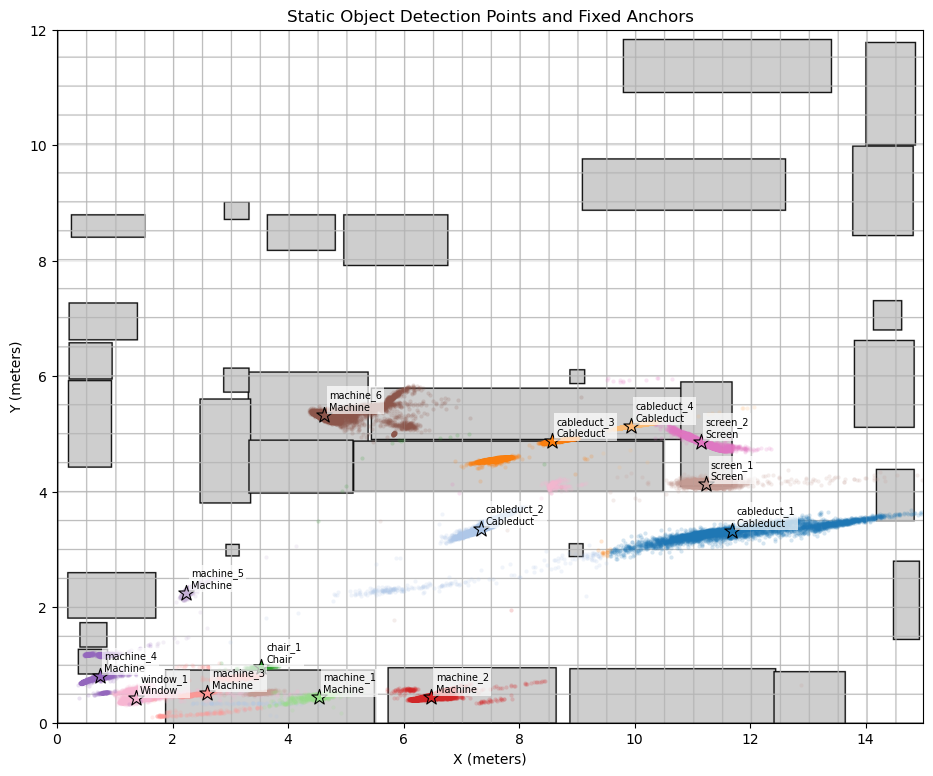

In [4]:

LABEL_FILTER = None
MAX_POINTS = None

fig, ax, plotted_anchors = plot_static_clusters(
    integrated_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    layout_path=config.LAYOUT_IMAGE,
    label_filter=LABEL_FILTER,
    max_points=MAX_POINTS,
)
preview_path = config.INTEGRATION_OUTPUT_DIR / 'dbscan_global_preview.png'
fig.savefig(preview_path, dpi=140, bbox_inches='tight')
print(f"Plotted DBSCAN anchors: {len(plotted_anchors)}")
print(preview_path)
#display(fig)



## KMeans

Run global KMeans clustering with a fixed cluster count, then plot the learned anchors.


In [5]:
'''
KMEANS_PARAMS_BY_LABEL = {
    'Cableduct': {'n_clusters': 7},
    'Machine': {'n_clusters': 6},
    'Screen': {'n_clusters': 2},
    'Window': {'n_clusters': 1},
}
KMEANS_RANDOM_STATE = 12345  # Fallback only if a label does not set random_state.

kmeans_args = SimpleNamespace(
    input_csv=config.FINAL_TABLE_CSV,
    output_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    frame_iou_threshold=0.35,
    frame_projected_distance_threshold=0.50,
    track_distance_threshold=0.60,
    track_person=False,
    static_clustering='kmeans_by_label',
    kmeans_params_by_label=KMEANS_PARAMS_BY_LABEL,
    kmeans_random_state=KMEANS_RANDOM_STATE,
)

raw_rows, deduped_rows, kmeans_rows, kmeans_registry = integrate_objects(kmeans_args)
{
    'method': 'kmeans_by_label',
    'kmeans_params_by_label': KMEANS_PARAMS_BY_LABEL,
    'kmeans_random_state': KMEANS_RANDOM_STATE,
    'raw_rows': len(raw_rows),
    'deduped_rows': len(deduped_rows),
    'integrated_rows': len(kmeans_rows),
    'static_objects': len(kmeans_registry),
}
'''

"\nKMEANS_PARAMS_BY_LABEL = {\n    'Cableduct': {'n_clusters': 7},\n    'Machine': {'n_clusters': 6},\n    'Screen': {'n_clusters': 2},\n    'Window': {'n_clusters': 1},\n}\nKMEANS_RANDOM_STATE = 12345  # Fallback only if a label does not set random_state.\n\nkmeans_args = SimpleNamespace(\n    input_csv=config.FINAL_TABLE_CSV,\n    output_csv=config.INTEGRATED_OBJECTS_CSV,\n    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,\n    frame_iou_threshold=0.35,\n    frame_projected_distance_threshold=0.50,\n    track_distance_threshold=0.60,\n    track_person=False,\n    static_clustering='kmeans_by_label',\n    kmeans_params_by_label=KMEANS_PARAMS_BY_LABEL,\n    kmeans_random_state=KMEANS_RANDOM_STATE,\n)\n\nraw_rows, deduped_rows, kmeans_rows, kmeans_registry = integrate_objects(kmeans_args)\n{\n    'method': 'kmeans_by_label',\n    'kmeans_params_by_label': KMEANS_PARAMS_BY_LABEL,\n    'kmeans_random_state': KMEANS_RANDOM_STATE,\n    'raw_rows': len(raw_rows),\n    'deduped_rows': len(de

In [6]:
'''
LABEL_FILTER = None
MAX_POINTS = None

fig, ax, plotted_anchors = plot_static_clusters(
    integrated_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    layout_path=config.LAYOUT_IMAGE,
    label_filter=LABEL_FILTER,
    max_points=MAX_POINTS,
)
preview_path = config.INTEGRATION_OUTPUT_DIR / 'kmeans_global_preview.png'
fig.savefig(preview_path, dpi=140, bbox_inches='tight')
print(f"Plotted KMeans anchors: {len(plotted_anchors)}")
print(preview_path)
#display(fig)
'''

'\nLABEL_FILTER = None\nMAX_POINTS = None\n\nfig, ax, plotted_anchors = plot_static_clusters(\n    integrated_csv=config.INTEGRATED_OBJECTS_CSV,\n    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,\n    layout_path=config.LAYOUT_IMAGE,\n    label_filter=LABEL_FILTER,\n    max_points=MAX_POINTS,\n)\npreview_path = config.INTEGRATION_OUTPUT_DIR / \'kmeans_global_preview.png\'\nfig.savefig(preview_path, dpi=140, bbox_inches=\'tight\')\nprint(f"Plotted KMeans anchors: {len(plotted_anchors)}")\nprint(preview_path)\n#display(fig)\n'

## GMM

Run global GMM clustering with BIC model selection, then plot the learned anchors.


In [7]:
'''
GMM_PARAMS_BY_LABEL = {
    'Cableduct': {'max_components': 7},
    'Machine': {'max_components': 6},
    'Screen': {'max_components': 2},
    'Window': {'max_components': 1},
}
GMM_RANDOM_STATE = 42  # Fallback only if a label does not set random_state.

gmm_args = SimpleNamespace(
    input_csv=config.FINAL_TABLE_CSV,
    output_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    frame_iou_threshold=0.35,
    frame_projected_distance_threshold=0.50,
    track_distance_threshold=0.60,
    track_person=False,
    static_clustering='gmm_by_label',
    gmm_params_by_label=GMM_PARAMS_BY_LABEL,
    gmm_random_state=GMM_RANDOM_STATE,
)

raw_rows, deduped_rows, gmm_rows, gmm_registry = integrate_objects(gmm_args)
{
    'method': 'gmm_by_label',
    'gmm_params_by_label': GMM_PARAMS_BY_LABEL,
    'gmm_random_state': GMM_RANDOM_STATE,
    'raw_rows': len(raw_rows),
    'deduped_rows': len(deduped_rows),
    'integrated_rows': len(gmm_rows),
    'static_objects': len(gmm_registry),
}

'''

"\nGMM_PARAMS_BY_LABEL = {\n    'Cableduct': {'max_components': 7},\n    'Machine': {'max_components': 6},\n    'Screen': {'max_components': 2},\n    'Window': {'max_components': 1},\n}\nGMM_RANDOM_STATE = 42  # Fallback only if a label does not set random_state.\n\ngmm_args = SimpleNamespace(\n    input_csv=config.FINAL_TABLE_CSV,\n    output_csv=config.INTEGRATED_OBJECTS_CSV,\n    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,\n    frame_iou_threshold=0.35,\n    frame_projected_distance_threshold=0.50,\n    track_distance_threshold=0.60,\n    track_person=False,\n    static_clustering='gmm_by_label',\n    gmm_params_by_label=GMM_PARAMS_BY_LABEL,\n    gmm_random_state=GMM_RANDOM_STATE,\n)\n\nraw_rows, deduped_rows, gmm_rows, gmm_registry = integrate_objects(gmm_args)\n{\n    'method': 'gmm_by_label',\n    'gmm_params_by_label': GMM_PARAMS_BY_LABEL,\n    'gmm_random_state': GMM_RANDOM_STATE,\n    'raw_rows': len(raw_rows),\n    'deduped_rows': len(deduped_rows),\n    'integrated_rows'

In [8]:
'''
LABEL_FILTER = None
MAX_POINTS = None

fig, ax, plotted_anchors = plot_static_clusters(
    integrated_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    layout_path=config.LAYOUT_IMAGE,
    label_filter=LABEL_FILTER,
    max_points=MAX_POINTS,
)
preview_path = config.INTEGRATION_OUTPUT_DIR / 'gmm_global_preview.png'
fig.savefig(preview_path, dpi=140, bbox_inches='tight')
print(f"Plotted GMM anchors: {len(plotted_anchors)}")
print(preview_path)
#display(fig)

'''

'\nLABEL_FILTER = None\nMAX_POINTS = None\n\nfig, ax, plotted_anchors = plot_static_clusters(\n    integrated_csv=config.INTEGRATED_OBJECTS_CSV,\n    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,\n    layout_path=config.LAYOUT_IMAGE,\n    label_filter=LABEL_FILTER,\n    max_points=MAX_POINTS,\n)\npreview_path = config.INTEGRATION_OUTPUT_DIR / \'gmm_global_preview.png\'\nfig.savefig(preview_path, dpi=140, bbox_inches=\'tight\')\nprint(f"Plotted GMM anchors: {len(plotted_anchors)}")\nprint(preview_path)\n#display(fig)\n\n'

## Projection Variation Check

Show how much each static object's original projected position varies around its learned anchor.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

variation_df = pd.read_csv(config.INTEGRATED_OBJECTS_CSV)
variation_df = variation_df[variation_df['people_or_machine'] == 'machine'].copy()
numeric_cols = ['projected_x', 'projected_y', 'anchor_x', 'anchor_y']
for col in numeric_cols:
    variation_df[col] = pd.to_numeric(variation_df[col], errors='coerce')
variation_df = variation_df.dropna(subset=numeric_cols)

variation_df['dx_m'] = variation_df['projected_x'] - variation_df['anchor_x']
variation_df['dy_m'] = variation_df['projected_y'] - variation_df['anchor_y']
variation_df['variation_m'] = np.sqrt(variation_df['dx_m'] ** 2 + variation_df['dy_m'] ** 2)

variation_summary = (
    variation_df.groupby(['object_id', 'canonical_label'], dropna=False)['variation_m']
    .agg(count='count', median='median', p90=lambda s: s.quantile(0.90), p95=lambda s: s.quantile(0.95), max='max')
    .reset_index()
    .sort_values('p95', ascending=False)
)
variation_summary.head(20)


,object_id,canonical_label,count,median,p90,p95,max
13,window_1,Window,2587,0.192541,1.283667,8.095218,8.641101
4,chair_1,Chair,201,0.122328,0.427200,3.458514,6.018815
0,cableduct_1,Cableduct,4905,0.630781,1.804933,2.102055,3.584185
10,machine_6,Machine,7596,0.103841,1.036945,1.268089,4.464958
2,cableduct_3,Cableduct,9888,0.127830,1.081513,1.145162,2.196029
7,machine_3,Machine,717,0.426625,0.844788,0.904862,1.035829
1,cableduct_2,Cableduct,6527,0.149705,0.570507,0.744874,6.264284
5,machine_1,Machine,537,0.134603,0.500326,0.615309,0.963027
11,screen_1,Screen,9081,0.147161,0.319987,0.473059,9.108047
9,machine_5,Machine,587,0.076069,0.290920,0.464057,2.061691


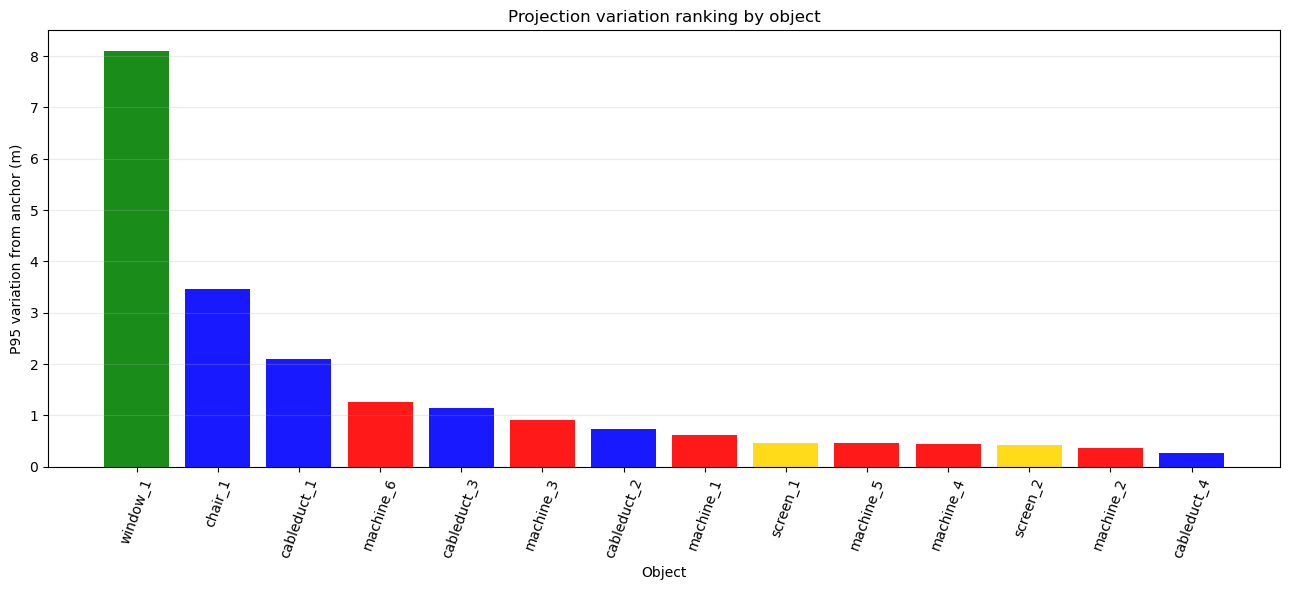

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_df = variation_summary.sort_values('p95', ascending=False)
colors = {'Machine': 'red', 'Cableduct': 'blue', 'Screen': 'gold', 'Window': 'green', 'Chair': 'blue'}
bar_colors = [colors.get(label, '#6f6f6f') for label in plot_df['canonical_label']]
ax.bar(plot_df['object_id'], plot_df['p95'], color=bar_colors, alpha=0.9)
ax.set_title('Projection variation ranking by object')
ax.set_xlabel('Object')
ax.set_ylabel('P95 variation from anchor (m)')
ax.tick_params(axis='x', rotation=70)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()


## Anchor Layout Check

Show the learned object anchors on the cleanroom layout after variation ranking.


Anchors shown: 14


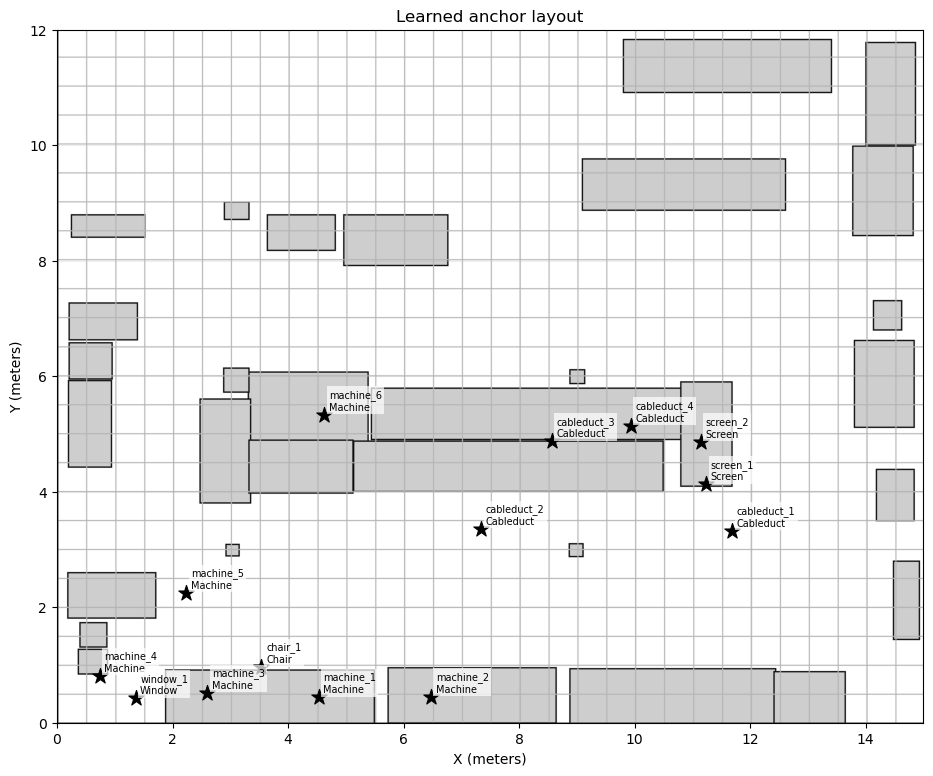

In [11]:
anchor_layout_df = variation_df[['object_id', 'canonical_label', 'anchor_x', 'anchor_y']].drop_duplicates('object_id')

fig, ax, plotted_anchors = plot_static_clusters(
    integrated_csv=config.INTEGRATED_OBJECTS_CSV,
    registry_csv=config.STATIC_OBJECT_REGISTRY_CSV,
    layout_path=config.LAYOUT_IMAGE,
    label_filter=None,
    max_points=0,
    point_alpha=0.0,
)
ax.set_title('Learned anchor layout')
print(f"Anchors shown: {len(plotted_anchors)}")


## Outlier Count Check

Show how many static-object points were treated as clustering outliers for each label.



,canonical_label,outlier_status,rows,total_rows,share
0,Cableduct,DBSCAN outlier -> nearest same-label anchor,417,28448,1.47
1,Cableduct,assigned to anchor,28031,28448,98.53
2,Chair,DBSCAN outlier -> nearest same-label anchor,13,201,6.47
3,Chair,assigned to anchor,188,201,93.53
4,Machine,DBSCAN outlier -> nearest same-label anchor,83,16662,0.50
5,Machine,assigned to anchor,16579,16662,99.50
6,Screen,DBSCAN outlier -> nearest same-label anchor,433,16840,2.57
7,Screen,assigned to anchor,16407,16840,97.43
8,Window,DBSCAN outlier -> nearest same-label anchor,335,2587,12.95
9,Window,assigned to anchor,2252,2587,87.05


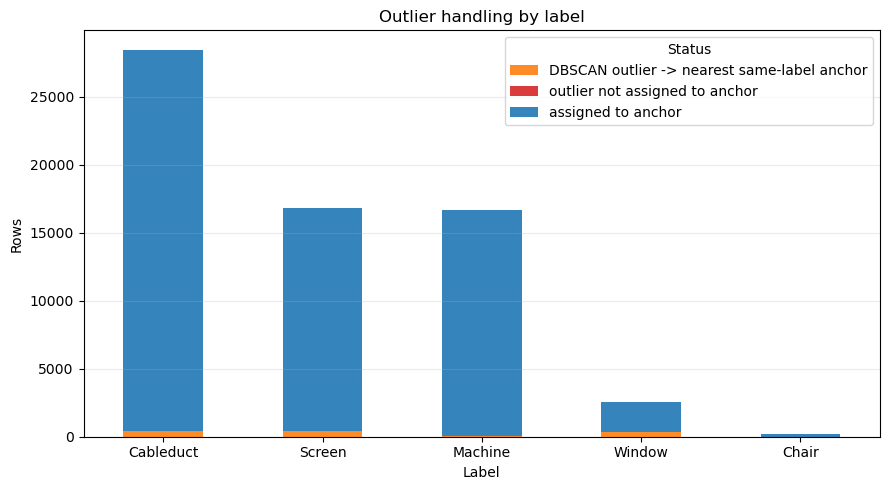

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

outlier_df = pd.read_csv(config.INTEGRATED_OBJECTS_CSV)
outlier_df = outlier_df[outlier_df['people_or_machine'] == 'machine'].copy()

for col in ['canonical_label', 'position_source', 'static_cluster_id', 'clustering_method']:
    if col not in outlier_df.columns:
        outlier_df[col] = ''
    outlier_df[col] = outlier_df[col].fillna('').astype(str)

outlier_df['outlier_status'] = 'assigned to anchor'
outlier_df.loc[
    outlier_df['position_source'].str.contains('nearest_same_label_anchor', case=False, na=False),
    'outlier_status',
] = 'DBSCAN outlier -> nearest same-label anchor'
outlier_df.loc[
    outlier_df['position_source'].str.contains('noise_frame_projection', case=False, na=False)
    | outlier_df['static_cluster_id'].str.lower().eq('noise')
    | outlier_df['clustering_method'].str.contains('noise', case=False, na=False),
    'outlier_status',
] = 'outlier not assigned to anchor'

outlier_summary = (
    outlier_df.groupby(['canonical_label', 'outlier_status'], dropna=False)
    .size()
    .reset_index(name='rows')
)
label_totals = (
    outlier_df.groupby('canonical_label', dropna=False)
    .size()
    .reset_index(name='total_rows')
)
outlier_summary = outlier_summary.merge(label_totals, on='canonical_label', how='left')
outlier_summary['share'] = outlier_summary['rows'] / outlier_summary['total_rows']

status_order = [
    'DBSCAN outlier -> nearest same-label anchor',
    'outlier not assigned to anchor',
    'assigned to anchor',
]
plot_counts = (
    outlier_summary
    .pivot(index='canonical_label', columns='outlier_status', values='rows')
    .reindex(columns=status_order)
    .fillna(0)
)
plot_counts = plot_counts.loc[plot_counts.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = {
    'DBSCAN outlier -> nearest same-label anchor': '#ff7f0e',
    'outlier not assigned to anchor': '#d62728',
    'assigned to anchor': '#1f77b4',
}
plot_counts.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[bar_colors.get(col, '#6f6f6f') for col in plot_counts.columns],
    alpha=0.9,
)
ax.set_title('Outlier handling by label')
ax.set_xlabel('Label')
ax.set_ylabel('Rows')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Status', loc='best')
fig.tight_layout()

display(
    outlier_summary
    .sort_values(['canonical_label', 'outlier_status'])
    .assign(share=lambda df: (df['share'] * 100).round(2))
)




## Object Assignment Debug

Use this area to find objects where the original YOLO `label` does not match the learned `canonical_label`. These rows are likely candidates for wrong static-object assignment before they reach `06` and `07`.


In [13]:
debug_integrated = pd.read_csv(config.INTEGRATED_OBJECTS_CSV)
debug_registry = pd.read_csv(config.STATIC_OBJECT_REGISTRY_CSV)

# Focus on static machine-side objects; people are not assigned as static anchors here.
debug_static = debug_integrated[debug_integrated['people_or_machine'] == 'machine'].copy()

label_mix = (
    debug_static
    .groupby(['object_id', 'canonical_label', 'label'], dropna=False)
    .size()
    .reset_index(name='rows')
    .sort_values(['object_id', 'rows'], ascending=[True, False])
)

label_totals = (
    debug_static
    .groupby(['object_id', 'canonical_label'], dropna=False)
    .size()
    .reset_index(name='object_rows')
)

label_mix = label_mix.merge(label_totals, on=['object_id', 'canonical_label'], how='left')
label_mix['label_share'] = label_mix['rows'] / label_mix['object_rows']
label_mismatch = label_mix[label_mix['label'] != label_mix['canonical_label']].copy()

print(f"Objects: {debug_static['object_id'].nunique()}")
print(f"Rows with label != canonical_label: {int(label_mismatch['rows'].sum())}")
display(label_mismatch.sort_values(['rows', 'label_share'], ascending=False))


Objects: 14
Rows with label != canonical_label: 0


,object_id,canonical_label,label,rows,object_rows,label_share


In [14]:
# Pick one object/date to inspect. Example: DEBUG_OBJECT_ID = 'screen_2', DEBUG_DATE = '2025-04-25'.
DEBUG_OBJECT_ID = 'screen_2'
DEBUG_DATE = None  # Set None to inspect all dates for this object.
SHOW_ONLY_MISMATCH = False

object_debug = debug_static[debug_static['object_id'] == DEBUG_OBJECT_ID].copy()
if DEBUG_DATE is not None:
    object_debug['timestamp_dt'] = pd.to_datetime(object_debug['timestamp'])
    object_debug = object_debug[object_debug['timestamp_dt'].dt.date.astype(str) == DEBUG_DATE]
if SHOW_ONLY_MISMATCH:
    object_debug = object_debug[object_debug['label'] != object_debug['canonical_label']]

inspect_cols = [
    'timestamp', 'image_name', 'detection_index',
    'label', 'canonical_label', 'object_id', 'merge_role',
    'projected_x', 'projected_y', 'anchor_x', 'anchor_y', 'display_x', 'display_y',
    'temp_mean_c', 'temp_max_c', 'confidence',
]
inspect_cols = [col for col in inspect_cols if col in object_debug.columns]

print(f"Rows for {DEBUG_OBJECT_ID}: {len(object_debug)}")
display(debug_registry[debug_registry['object_id'] == DEBUG_OBJECT_ID])
display(object_debug[inspect_cols].sort_values('timestamp').head(100))


Rows for screen_2: 7759


,object_id,people_or_machine,canonical_label,static_cluster_id,label_counts,mean_projected_x,mean_projected_y,anchor_x,anchor_y,observations,...,dbscan_label,dbscan_min_samples,kmeans_clusters,kmeans_label,kmeans_random_state,gmm_selected_components,gmm_bic,gmm_max_components,gmm_label,gmm_random_state
12,screen_2,machine,Screen,dbscan_screen_0000,Screen:7692,11.148436,4.869258,11.149738,4.865085,7692,...,Screen,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,timestamp,image_name,detection_index,label,canonical_label,object_id,merge_role,projected_x,projected_y,anchor_x,anchor_y,display_x,display_y,temp_mean_c,temp_max_c,confidence
13,2025-04-23 13:29:02,IR_57328.jpg,8,Screen,Screen,screen_2,keep,10.830623,5.017345,11.149738,4.865085,11.149738,4.865085,21.843969,32.599998,0.415888
29,2025-04-23 13:30:02,IR_57330.jpg,3,Screen,Screen,screen_2,keep,10.879442,4.983553,11.149738,4.865085,11.149738,4.865085,21.458889,25.793211,0.777978
39,2025-04-23 13:30:32,IR_57331.jpg,8,Screen,Screen,screen_2,keep,11.177906,4.852796,11.149738,4.865085,11.149738,4.865085,21.767385,27.299999,0.514369
49,2025-04-23 13:31:03,IR_57332.jpg,7,Screen,Screen,screen_2,keep,10.936293,4.957119,11.149738,4.865085,11.149738,4.865085,21.425896,25.764229,0.565240
59,2025-04-23 13:31:32,IR_57333.jpg,8,Screen,Screen,screen_2,keep,11.071144,4.890030,11.149738,4.865085,11.149738,4.865085,21.576462,25.796345,0.528071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,2025-04-23 14:19:03,IR_57428.jpg,3,Screen,Screen,screen_2,keep,10.863238,4.976652,11.149738,4.865085,11.149738,4.865085,21.100502,26.276239,0.657499
1004,2025-04-23 14:19:32,IR_57429.jpg,3,Screen,Screen,screen_2,keep,10.852661,4.975761,11.149738,4.865085,11.149738,4.865085,21.158743,26.305744,0.649945
1013,2025-04-23 14:20:02,IR_57430.jpg,2,Screen,Screen,screen_2,keep,10.850410,4.993838,11.149738,4.865085,11.149738,4.865085,21.273973,26.596344,0.803058
1021,2025-04-23 14:20:32,IR_57431.jpg,4,Screen,Screen,screen_2,keep,11.188132,4.841463,11.149738,4.865085,11.149738,4.865085,21.383062,27.500000,0.565205


In [15]:
# Show the hottest rows for the selected object. Useful for checking whether spikes come from wrong labels.
HOTTEST_N = 30
hot_cols = [
    'timestamp', 'image_name', 'detection_index',
    'label', 'canonical_label', 'object_id',
    'temp_mean_c', 'temp_max_c',
    'projected_x', 'projected_y', 'anchor_x', 'anchor_y', 'display_x', 'display_y',
]
hot_cols = [col for col in hot_cols if col in object_debug.columns]

display(
    object_debug[hot_cols]
    .sort_values('temp_mean_c', ascending=False)
    .head(HOTTEST_N)
)


,timestamp,image_name,detection_index,label,canonical_label,object_id,temp_mean_c,temp_max_c,projected_x,projected_y,anchor_x,anchor_y,display_x,display_y
61082,2025-05-06 13:05:44,IR_65180.jpg,4,Screen,Screen,screen_2,26.547829,33.400002,11.102939,4.880299,11.149738,4.865085,11.149738,4.865085
61634,2025-05-06 14:09:44,IR_65308.jpg,4,Screen,Screen,screen_2,26.200718,33.900002,10.799662,5.012603,11.149738,4.865085,11.149738,4.865085
61488,2025-05-06 13:51:44,IR_65272.jpg,3,Screen,Screen,screen_2,26.087690,33.200001,10.778324,5.040107,11.149738,4.865085,11.149738,4.865085
61370,2025-05-06 13:37:45,IR_65244.jpg,5,Screen,Screen,screen_2,25.948860,33.400002,10.757919,5.016525,11.149738,4.865085,11.149738,4.865085
34201,2025-04-29 12:59:38,IR_61008.jpg,8,Screen,Screen,screen_2,25.833685,32.500000,10.834862,4.989105,11.149738,4.865085,11.149738,4.865085
34637,2025-04-29 13:30:38,IR_61070.jpg,13,Screen,Screen,screen_2,25.600008,35.299999,10.662749,5.009536,11.149738,4.865085,11.149738,4.865085
45226,2025-05-01 09:38:51,IR_62581.jpg,3,Screen,Screen,screen_2,25.503073,34.299999,10.617723,5.047912,11.149738,4.865085,11.149738,4.865085
34647,2025-04-29 13:31:08,IR_61071.jpg,6,Screen,Screen,screen_2,25.485226,33.599998,10.871840,4.962711,11.149738,4.865085,11.149738,4.865085
61544,2025-05-06 13:58:15,IR_65285.jpg,3,Screen,Screen,screen_2,25.238104,33.799999,11.151840,4.872597,11.149738,4.865085,11.149738,4.865085
61193,2025-05-06 13:18:15,IR_65205.jpg,6,Screen,Screen,screen_2,25.237377,32.400002,10.690947,5.022814,11.149738,4.865085,11.149738,4.865085


In [16]:
# Trace selected rows back to the projected detection CSV from 04.
# This helps decide whether the issue came from YOLO/projection or from 05 object assignment.
DEBUG_IMAGE_NAME = None  # Example: object_debug.iloc[0]['image_name']
DEBUG_DETECTION_INDEX = None  # Example: int(object_debug.iloc[0]['detection_index'])

if DEBUG_IMAGE_NAME is not None:
    projected_debug = pd.read_csv(config.PROJECTED_DETECTIONS_CSV)
    projected_match = projected_debug[projected_debug['image_name'] == DEBUG_IMAGE_NAME].copy()
    if DEBUG_DETECTION_INDEX is not None and 'detection_index' in projected_match.columns:
        projected_match = projected_match[projected_match['detection_index'] == DEBUG_DETECTION_INDEX]
    display(projected_match)
else:
    print('Set DEBUG_IMAGE_NAME and optionally DEBUG_DETECTION_INDEX to trace one row back to 04 projected detections.')


Set DEBUG_IMAGE_NAME and optionally DEBUG_DETECTION_INDEX to trace one row back to 04 projected detections.
